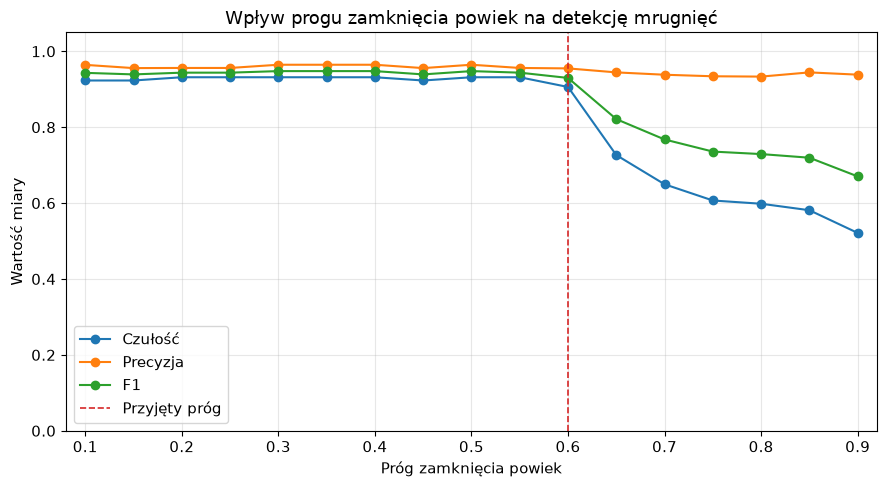

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

from src.analyze import run_analysis
from src.detection_config import DetectionConfig, ScenarioConfig
from src.reports import build_blink_evaluation

thresholds = [value / 100 for value in range(10, 91, 5)]
participants = [f"participant_{number}" for number in range(1, 5)]

rows = []

for threshold in thresholds:
    result = run_analysis(
        DetectionConfig(blink_threshold=threshold),
        ScenarioConfig(),
    )

    evaluation = build_blink_evaluation(
        result.blink_matches,
        result.events,
    )

    selected = evaluation[
        (evaluation["scenario"] == "blink")
        & evaluation["participant"].isin(participants)
    ]

    tp, fp, fn = selected[["tp", "fp", "fn"]].sum()

    rows.append(
        {
            "threshold": threshold,
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "recall": tp / (tp + fn),
            "precision": tp / (tp + fp) if tp + fp else float("nan"),
            "f1": 2 * tp / (2 * tp + fp + fn),
        }
    )

results = pd.DataFrame(rows)

baseline = results.loc[results["threshold"] == 0.60].iloc[0]
assert (baseline["tp"], baseline["fp"], baseline["fn"]) == (106, 5, 11)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    results["threshold"],
    results["recall"],
    marker="o",
    color="tab:blue",
    label="Czułość",
)

ax.plot(
    results["threshold"],
    results["precision"],
    marker="o",
    color="tab:orange",
    label="Precyzja",
)

ax.plot(
    results["threshold"],
    results["f1"],
    marker="o",
    color="tab:green",
    label="F1",
)

ax.axvline(
    0.60,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label="Przyjęty próg",
)

ax.set(
    title="Wpływ progu zamknięcia powiek na detekcję mrugnięć",
    xlabel="Próg zamknięcia powiek",
    ylabel="Wartość miary",
    xlim=(0.08, 0.92),
    ylim=(0.0, 1.05),
)

ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

plt.show()